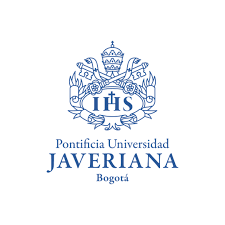
***Pontificia Universidad Javeriana***
# **Procesamiento de Alto Volumen de Datos**

### Taller: **Tratamiento de Datos y Machine Learning con PySpark**

Autor: Felix David Córdova Garcia

Fecha de Inicio: 21 de mayo del 2026

Fecha actual: 28 de mayo del 2026

## **Problemática**

Se tiene que el tratamiento del agua debe ser indispensable para garantizar la pureza y la calidad. Uno de los elementos significativos es aplicar los conceptos de los Procesamientos de Datos en Alto Volúmen para solucionar este tipo de problemas que afectan la salud publica. El presente ejemplo tiene como propósito tener en cuenta una metodogología para aplicar el PAVD para solucionar o diagnósticar la calidad del agua en la INDIA.

## **Objetivo**

Implementar modelos de predicción utilizando la biblioteca de aprendizaje automático MLlib PySpark, con el fin de explorar y aplicar técnicas de IA en entornos de procesamiento con alto volúmen de datos.


## **Metodología**

1.- Importación de los datos (datos en diferentes formatos)

2.- Preprocesamiento y limpieza de valores nulos, cambio de datos, EDA, medidas estadísticas.

3.- Entrenamiento de modelos: RL (MLlib), tensores (KERAS); la idea es predecir la calidad del agua en la INDIA.

4.- Evaluación de los modelos: medidas de rendimiento tales como: precisión (precision), exactitud (accuracy), recall, F1 Score,entre otras.

5.- Se tiene como referencia de la calidad de los parámetros del agua, la referencia: https://www.intechopen.com/chapters/69568

## **1.- Importación de bibliotecas**

In [44]:
# Se agregan las rutas del sistema necesarias para el entorno del clúster
import os
import sys
sys.path.append('/usr/lib/python3/dist-packages/')

# Se importan las bibliotecas de cálculo numérico y manipulación de datos
import numpy as np
import pandas as pd

# Se importan las bibliotecas de visualización
import seaborn as sns
import matplotlib.pyplot as plt
from pylab import *

# Se inicializa findspark para localizar la instalación de PySpark en el sistema
import findspark
findspark.init()

# Se importan los módulos principales de PySpark para el procesamiento distribuido
import pyspark.sql.functions as F
from pyspark import SparkConf, SparkContext
from pyspark.sql import SQLContext
from pyspark.sql import SparkSession
from pyspark.sql.types import *

print("Bibliotecas cargadas correctamente")

Bibliotecas cargadas correctamente


In [65]:
# Se detiene cualquier sesión activa antes de crear una nueva
# Esto garantiza que se use el nombre de aplicación correcto
session_activa = SparkSession.getActiveSession()
if session_activa:
  session_activa.stop()

# Se configura la aplicación Spark con el nombre identificador del estudiante
config = SparkConf()
config.setAppName("Calidad_De_Agua_Cordova")

# Se crea la sesión Spark con la configuración nueva
sparkC = SparkSession.builder.config(conf=config).getOrCreate()

SQLContext(sparkContext=sparkC.sparkContext, sparkSession=sparkC)
sparkContextoC = sparkC.sparkContext.getOrCreate()

SQLContext(sparkContext=sparkC.sparkContext, sparkSession=sparkC)
sparkContextoC = sparkC.sparkContext.getOrCreate()

print("Sesion creada: ProcesamientoDatos")
print(f"Nombre de la aplicacion: {sparkC.sparkContext.appName}")
sparkC

Sesion creada: ProcesamientoDatos
Nombre de la aplicacion: Calidad_De_Agua_Cordova


26/05/27 14:45:47 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/05/27 14:45:47 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


In [66]:
# Se lista el contenido del directorio /csv en HDFS para verificar la disponibilidad del archivo
!/mnt/sda1/Cluster/Hadoop/bin/hadoop fs -ls /csv

# Se carga el archivo CSV desde HDFS hacia un DataFrame de Spark
# La opción 'header=true' indica que la primera fila contiene los nombres de las columnas
df00 = sparkC.read.format("csv").option("header", "true").load("hdfs://10.195.34.34:9000/csv/waterquality.csv")

# Se muestran las primeras 5 filas del DataFrame para verificar la carga correcta
df00.show(5)

Found 11 items
-rw-r--r--   2 sistemas supergroup     977501 2026-03-10 15:27 /csv/CustomerChurn.csv
-rw-r--r--   2 sistemas supergroup      40868 2025-07-07 15:41 /csv/Fortune500USCompanies.csv
drwxr-xr-x   - sistemas supergroup          0 2025-10-16 14:17 /csv/auxiliar
-rw-r--r--   2 sistemas supergroup    4610348 2026-04-28 08:17 /csv/bank-full.csv
-rw-r--r--   2 sistemas supergroup      34635 2025-09-02 13:22 /csv/jugadores.csv
-rw-r--r--   2 sistemas supergroup    1082023 2025-09-02 13:22 /csv/resultados_futbol.csv
-rw-r--r--   2 sistemas supergroup     316971 2025-06-10 09:11 /csv/stroke_pyspark.csv
drwxr-xr-x   - sistemas supergroup          0 2025-06-18 15:36 /csv/taxi
drwxr-xr-x   - sistemas supergroup          0 2026-04-23 15:56 /csv/titanic
-rw-r--r--   2 sistemas supergroup      48036 2025-06-12 14:31 /csv/waterquality.csv
-rw-r--r--   2 sistemas supergroup      84199 2026-04-23 17:11 /csv/winequality-red.csv


[Stage 0:>                                                          (0 + 1) / 1]

+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|         735|3.4|                  2|             3|            73|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|  6|  8|         270|3.1|                  2|            72|           182|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|         355|4.2|                  9|            59|           133|
|        2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|5.5|7.8|         371|5.6|               3.55|            90|           283|
|        2183|GODAVARI RIVER AT...|MAHARASHTRA|25.7|5.7|7.9|         294|3.2|               2.69|       

## **3. Análisis y Preparación de Datos**

Se presentan datos (csv) con los diferentes parámetros de los ríos de la India.
Cada parámetro es el promedio de los valores medidos en un período de tiempo.
Los datos han sido extraídos de la web oficial de la India (RiverIndia).

### Descripción de columnas:
- **STATION CODE**: Código de estación de medida
- **LOCATIONS**: Ubicaciones de los ríos
- **STATE**: Estado de la India
- **TEMP**: Temperatura del agua en °C
- **DO**: Oxígeno Disuelto (mg/L). Concentraciones altas representan mejor calidad del agua
- **pH**: Logaritmo negativo de la concentración de hidrógeno. Indica la acidez del agua
- **CONDUCTIVITY**: Mide la habilidad de la solución para conducir corriente. El agua pura NO conduce
- **BOD**: Demanda Bioquímica de Oxígeno. Mayor cantidad de material orgánico = mayor BOD
- **NITRATE_N_NITRITE_N**: Nitratos/Nitritos. Altas concentraciones degradan la calidad del agua (mg/L)
- **FECAL_COLIFORM**: Promedio de bacterias coliformes fecales
- **TOTAL_COLIFORM**: Se elimina pues no aporta al estudio de predicción de la calidad del agua

In [67]:
# Se obtienen los nombres de todas las columnas del DataFrame para su revisión
print("Columnas del DataFrame:")
print(df00.columns)

Columnas del DataFrame:
['STATION CODE', 'LOCATIONS', 'STATE', 'TEMP', 'DO', 'pH', 'CONDUCTIVITY', 'BOD', 'NITRATE_N_NITRITE_N', 'FECAL_COLIFORM', 'TOTAL_COLIFORM']


In [68]:
# Se calculan y muestran las estadísticas descriptivas (count, mean, stddev, min, max)
# para cada columna del DataFrame de forma individual
for valor in df00.columns:
    df00.describe([valor]).show()

+-------+-----------------+
|summary|     STATION CODE|
+-------+-----------------+
|  count|              534|
|   mean|2052.516853932584|
| stddev|755.2178560086894|
|    min|             1023|
|    max|               41|
+-------+-----------------+

+-------+-------------------+
|summary|          LOCATIONS|
+-------+-------------------+
|  count|                534|
|   mean|               NULL|
| stddev|               NULL|
|    min|          AHMEDABAD|
|    max|ZUARI AT PANCHAWADI|
+-------+-------------------+

+-------+--------------+
|summary|         STATE|
+-------+--------------+
|  count|           534|
|   mean|          NULL|
| stddev|          NULL|
|    min|ANDHRA PRADESH|
|    max|   WEST BENGAL|
+-------+--------------+

+-------+------------------+
|summary|              TEMP|
+-------+------------------+
|  count|               534|
|   mean|25.241398865784515|
| stddev|3.4480130875026624|
|    min|              10.5|
|    max|                NA|
+-------+---------

### **Visualización de los Datos Nulos**

In [69]:
# Se cuenta la cantidad de valores nulos o imposibles (NaN/null) por cada columna
# Permite identificar columnas con datos faltantes antes del preprocesamiento
print("Cantidad de valores nulos por columna:")
df00.select([
    F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c)
    for c in df00.columns
]).show()

Cantidad de valores nulos por columna:
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|           0|        0|    0|   0|  0|  0|           0|  0|                  0|             0|             0|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+



In [70]:
# Se crea una vista temporal SQL del DataFrame original para realizar consultas
df00.createOrReplaceTempView("df00_sql")

# Se filtra el DataFrame conservando únicamente los registros sin valores nulos
# en los parámetros clave de calidad del agua
df01 = sparkC.sql('''
    Select * from df00_sql
    where TEMP is not null
    and DO is not null
    and pH is not null
    and CONDUCTIVITY is not null
    and BOD is not null
    and NITRATE_N_NITRITE_N is not null
    and FECAL_COLIFORM is not null
''')

print(f"Registros originales: {df00.count()}")
print(f"Registros tras filtro de nulos: {df01.count()}")

Registros originales: 534
Registros tras filtro de nulos: 534


In [71]:
# Se verifica que el DataFrame filtrado df01 no contenga valores nulos
print("Verificacion de nulos en df01 (debe ser 0 en todo):")
df01.select([
    F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c)
    for c in df01.columns
]).show()

Verificacion de nulos en df01 (debe ser 0 en todo):
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|           0|        0|    0|   0|  0|  0|           0|  0|                  0|             0|             0|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+



### **Tratamiento de Datos**

Se realiza la conversión de los tipos de datos de las columnas numéricas de String a Float,
ya que el formato CSV carga todos los campos como cadenas de texto por defecto.

In [72]:
# Se muestran los tipos de datos actuales antes de la transformación
print("Tipos de datos originales:")
print(df00.dtypes)

# Se convierten las columnas numéricas de tipo String a FloatType
# para permitir operaciones matemáticas y estadísticas sobre los datos
df00 = df00.withColumn('TEMP',               df00['TEMP'].cast(FloatType()))
df00 = df00.withColumn('pH',                 df00['pH'].cast(FloatType()))
df00 = df00.withColumn('DO',                 df00['DO'].cast(FloatType()))
df00 = df00.withColumn('CONDUCTIVITY',       df00['CONDUCTIVITY'].cast(FloatType()))
df00 = df00.withColumn('NITRATE_N_NITRITE_N',df00['NITRATE_N_NITRITE_N'].cast(FloatType()))
df00 = df00.withColumn('FECAL_COLIFORM',     df00['FECAL_COLIFORM'].cast(FloatType()))
df00 = df00.withColumn('BOD',                df00['BOD'].cast(FloatType()))

# Se verifica la conversión de tipos
print("\nTipos de datos tras conversion:")
print(df00.dtypes)

# Se elimina la columna TOTAL_COLIFORM por no aportar al modelo de predicción
df01 = df00.drop('TOTAL_COLIFORM')
print("\nColumnas de df01 (sin TOTAL_COLIFORM):")
print(df01.columns)

Tipos de datos originales:
[('STATION CODE', 'string'), ('LOCATIONS', 'string'), ('STATE', 'string'), ('TEMP', 'string'), ('DO', 'string'), ('pH', 'string'), ('CONDUCTIVITY', 'string'), ('BOD', 'string'), ('NITRATE_N_NITRITE_N', 'string'), ('FECAL_COLIFORM', 'string'), ('TOTAL_COLIFORM', 'string')]

Tipos de datos tras conversion:
[('STATION CODE', 'string'), ('LOCATIONS', 'string'), ('STATE', 'string'), ('TEMP', 'float'), ('DO', 'float'), ('pH', 'float'), ('CONDUCTIVITY', 'float'), ('BOD', 'float'), ('NITRATE_N_NITRITE_N', 'float'), ('FECAL_COLIFORM', 'float'), ('TOTAL_COLIFORM', 'string')]

Columnas de df01 (sin TOTAL_COLIFORM):
['STATION CODE', 'LOCATIONS', 'STATE', 'TEMP', 'DO', 'pH', 'CONDUCTIVITY', 'BOD', 'NITRATE_N_NITRITE_N', 'FECAL_COLIFORM']


## **4. Creación de Vectores para Visualizar los Datos**

Se hace uso de la función LAMBDA para extraer cada parámetro del DataFrame de Spark
y convertirlo en una lista de Python, necesaria para la visualización con matplotlib.

In [73]:
# Se crea una vista temporal SQL del DataFrame df01 para realizar consultas por parámetro
df01.createOrReplaceTempView("df01_sql")

# --- Parámetro DO (Oxígeno Disuelto) ---
# Se consulta la columna DO y se convierte a lista Python mediante la función lambda
do_parametro = sparkC.sql("Select DO from df01_sql")
do_parametro = do_parametro.rdd.map(lambda fila: fila.DO).collect()

# --- Parámetro pH ---
# Se consulta la columna pH y se extrae cada valor mediante la función lambda
ph_parametro = sparkC.sql("Select pH from df01_sql")
ph_parametro = ph_parametro.rdd.map(lambda fila: fila.pH).collect()

# --- Parámetro CONDUCTIVITY (Conductividad) ---
# Se consulta la columna CONDUCTIVITY y se extrae cada valor mediante la función lambda
COND_parametro = sparkC.sql("Select CONDUCTIVITY from df01_sql")
COND_parametro = COND_parametro.rdd.map(lambda fila: fila.CONDUCTIVITY).collect()

# --- Parámetro BOD (Demanda Bioquímica de Oxígeno) ---
# Se consulta la columna BOD y se extrae cada valor mediante la función lambda
BOD_parametro = sparkC.sql("Select BOD from df01_sql")
BOD_parametro = BOD_parametro.rdd.map(lambda fila: fila.BOD).collect()

# --- Parámetro NITRATE_N_NITRITE_N (Nitratos/Nitritos) ---
# Se consulta la columna NITRATE_N_NITRITE_N y se extrae cada valor mediante la función lambda
NN_parametro = sparkC.sql("Select NITRATE_N_NITRITE_N from df01_sql")
NN_parametro = NN_parametro.rdd.map(lambda fila: fila.NITRATE_N_NITRITE_N).collect()

# --- Parámetro FECAL_COLIFORM (Coliformes Fecales) ---
# Se consulta la columna FECAL_COLIFORM y se extrae cada valor mediante la función lambda
FC_parametro = sparkC.sql("Select FECAL_COLIFORM from df01_sql")
FC_parametro = FC_parametro.rdd.map(lambda fila: fila.FECAL_COLIFORM).collect()

print(f"Vectores creados correctamente. Cantidad de registros: {len(do_parametro)}")

Vectores creados correctamente. Cantidad de registros: 534


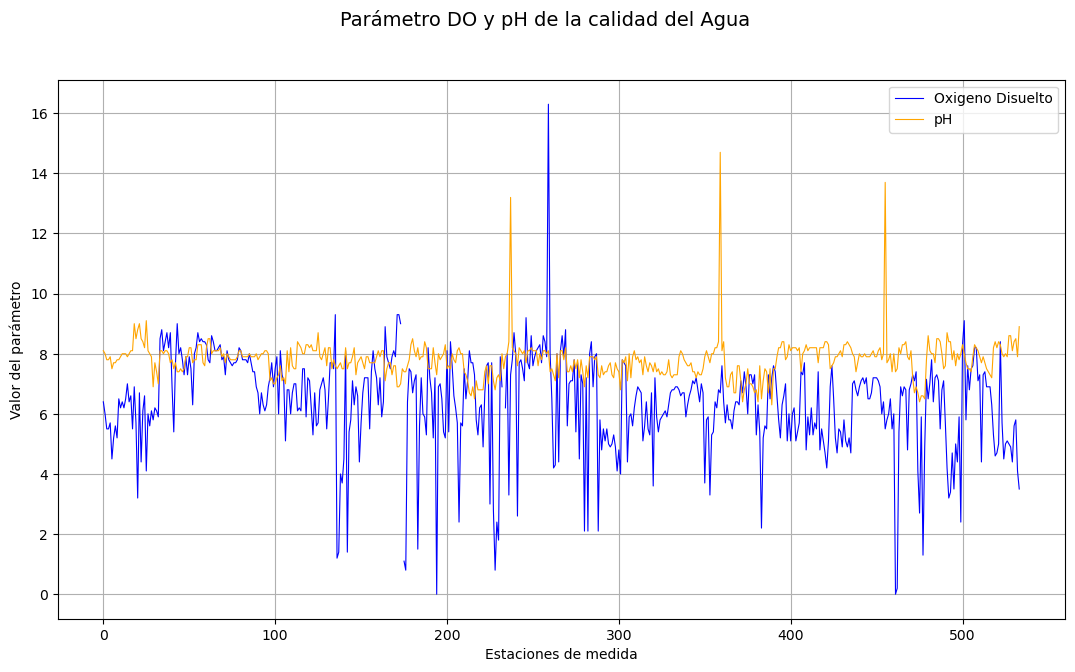

In [74]:
# Se grafican los parámetros DO y pH en una misma figura para comparar su comportamiento
# La longitud del vector determina el eje X (número de estaciones de medida)
tam = len(do_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13, 7), facecolor='w', edgecolor='k')

# Se traza la serie temporal de Oxígeno Disuelto
ax1.plot(range(0, tam), do_parametro, label='Oxigeno Disuelto', color='blue', linewidth=0.8)

# Se traza la serie temporal de pH
ax1.plot(range(0, tam), ph_parametro, label='pH', color='orange', linewidth=0.8)

# Se agregan los elementos de carpintería de la gráfica
fig.suptitle('Parámetro DO y pH de la calidad del Agua', fontsize=14)
ax1.set_xlabel('Estaciones de medida')
ax1.set_ylabel('Valor del parámetro')
legend = ax1.legend()
plt.grid()
plt.show()

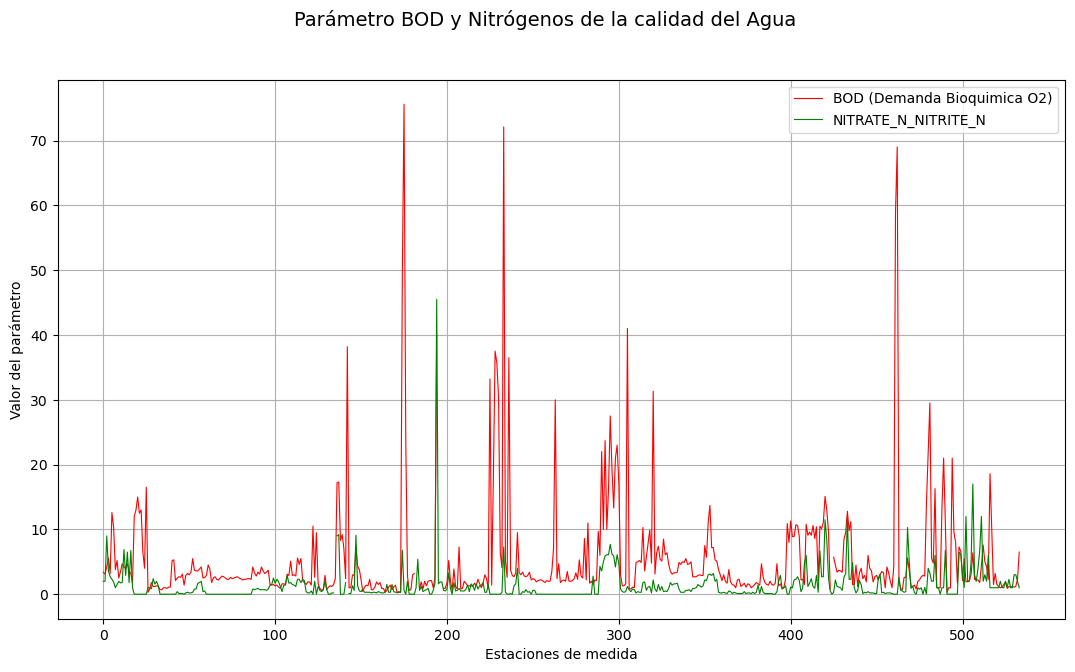

In [75]:
# Se grafican los parámetros BOD y Nitratos/Nitritos para analizar la contaminación orgánica
tam = len(do_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13, 7), facecolor='w', edgecolor='k')

# Se traza la serie de Demanda Bioquímica de Oxígeno
ax1.plot(range(0, tam), BOD_parametro, label='BOD (Demanda Bioquimica O2)', color='red', linewidth=0.8)

# Se traza la serie de Nitratos/Nitritos
ax1.plot(range(0, tam), NN_parametro, label='NITRATE_N_NITRITE_N', color='green', linewidth=0.8)

fig.suptitle('Parámetro BOD y Nitrógenos de la calidad del Agua', fontsize=14)
ax1.set_xlabel('Estaciones de medida')
ax1.set_ylabel('Valor del parámetro')
legend = ax1.legend()
plt.grid()
plt.show()

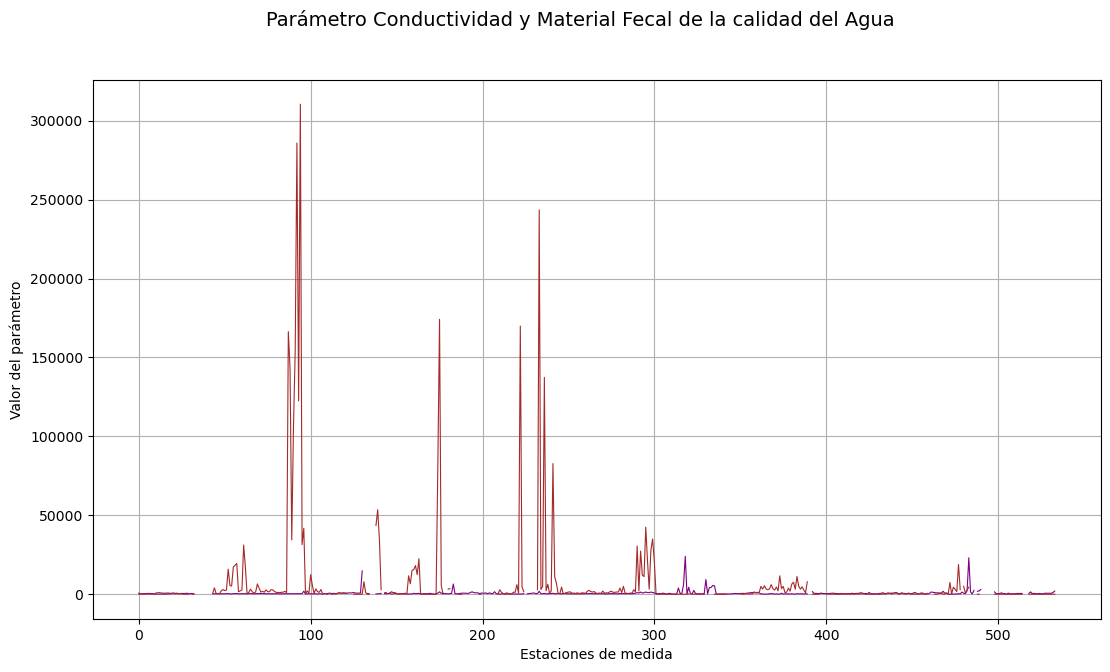

In [76]:
# Se grafican los parámetros de Conductividad y Coliformes Fecales
# para analizar la contaminación bacteriológica y mineral del agua
tam = len(do_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13, 7), facecolor='w', edgecolor='k')

# Se traza la serie de Conductividad eléctrica
ax1.plot(range(0, tam), COND_parametro, label='Conductividad', color='purple', linewidth=0.8)

# Se traza la serie de Coliformes Fecales
ax1.plot(range(0, tam), FC_parametro, label='Coliformes Fecales', color='brown', linewidth=0.8)

fig.suptitle('Parámetro Conductividad y Material Fecal de la calidad del Agua', fontsize=14)
ax1.set_xlabel('Estaciones de medida')
ax1.set_ylabel('Valor del parámetro')
plt.xlabel("Estaciones de medida")
plt.grid()
plt.show()

## **5. Creación de Rangos de Calidad del Agua**

Se crean columnas de rangos de calidad (0, 40, 60, 80, 100) para cada parámetro
según los intervalos definidos en la referencia bibliográfica:
https://www.intechopen.com/chapters/69568

In [77]:
# Se crea la columna 'qrPH' con el rango de calidad según el valor de pH
# pH óptimo para consumo humano: entre 7.0 y 8.5 (calidad = 100)
df02 = df01.withColumn("qrPH",
    F.when((df01.pH >= 7)   & (df01.pH <= 8.5), 100)
     .when(((df01.pH >= 6.8) & (df01.pH < 6.9))  | ((df01.pH > 8.5)  & (df01.pH < 8.6)),  80)
     .when(((df01.pH >= 6.7) & (df01.pH < 6.8))  | ((df01.pH >= 8.6) & (df01.pH < 8.8)),  60)
     .when(((df01.pH >= 6.5) & (df01.pH < 6.7))  | ((df01.pH >= 8.8) & (df01.pH < 9.0)),  40)
     .otherwise(0)
)
print("Columna qrPH creada correctamente")

Columna qrPH creada correctamente


In [86]:
# Función definida por el usuario para definir el rando de la calidad del agua según DO
# Se crea la columna 'qrDO' con el rango de calidad según el Oxígeno Disuelto
# DO >= 6.0 mg/L indica agua de buena calidad para la vida acuática (calidad = 100)
df02 = df02.withColumn("qrDO",
    F.when(df01.DO >= 6.0, 100)
     .when((df01.DO >= 5.1) & (df01.DO < 6.0),  80)
     .when((df01.DO >= 4.1) & (df01.DO < 5.0),  60)
     .when((df01.DO >= 3.0) & (df01.DO <= 4.0), 40)
     .otherwise(0)
)
print("Columna qrDO creada correctamente")

Columna qrDO creada correctamente


In [78]:
# Se crea la columna 'qrCOND' con el rango de calidad según la Conductividad
# Conductividad entre 0 y 75 µS/cm indica agua pura de alta calidad (calidad = 100)
df02 = df02.withColumn("qrCOND",
    F.when((df01.CONDUCTIVITY >= 0.0)   & (df01.CONDUCTIVITY <= 75.0),  100)
     .when((df01.CONDUCTIVITY > 75.0)   & (df01.CONDUCTIVITY <= 150.0),  80)
     .when((df01.CONDUCTIVITY > 150.0)  & (df01.CONDUCTIVITY <= 225.0),  60)
     .when((df01.CONDUCTIVITY > 225.0)  & (df01.CONDUCTIVITY <= 300.0),  40)
     .otherwise(0)
)
print("Columna qrCOND creada correctamente")

Columna qrCOND creada correctamente


In [79]:
# Se crea la columna 'qrBOD' con el rango de calidad según la Demanda Bioquímica de Oxígeno
# BOD < 3 mg/L indica agua limpia con poca materia orgánica (calidad = 100)
df02 = df02.withColumn("qrBOD",
    F.when((df01.BOD >= 0.0)  & (df01.BOD < 3.0),   100)
     .when((df01.BOD >= 3.0)  & (df01.BOD < 6.0),    80)
     .when((df01.BOD >= 6.0)  & (df01.BOD < 80.0),   60)
     .when((df01.BOD >= 80.0) & (df01.BOD < 125.0),  40)
     .otherwise(0)
)
print("Columna qrBOD creada correctamente")

Columna qrBOD creada correctamente


In [81]:
## Función definida por el usuario para definir el rando de la calidad del agua según NITRATE_N_NITRITE_N
### 100: Agua Dulce
### 80: Agua Moderada
### 60: Agua Dura
### 40: Agua muy Dura
df02 = df02.withColumn("qrNN",
    F.when((df01.NITRATE_N_NITRITE_N >= 0.0)   & (df01.NITRATE_N_NITRITE_N < 20.0),  100)
     .when((df01.NITRATE_N_NITRITE_N >= 20.0)  & (df01.NITRATE_N_NITRITE_N < 50.0),   80)
     .when((df01.NITRATE_N_NITRITE_N >= 50.0)  & (df01.NITRATE_N_NITRITE_N < 100.0),  60)
     .when((df01.NITRATE_N_NITRITE_N >= 100.0) & (df01.NITRATE_N_NITRITE_N < 200.0),  40)
     .otherwise(0)
)
print("Columna qrNN creada correctamente")

Columna qrNN creada correctamente


In [83]:
## Función definida por el usuario para definir el rando de la calidad del agua según el Material Fecal
### 100: Agua Dulce
### 80: Agua Moderada
### 60: Agua Dura
### 40: Agua muy Dura
df02 = df02.withColumn("qrFecal",
    F.when((df01.FECAL_COLIFORM >= 0.0)   & (df01.FECAL_COLIFORM < 5.0),    100)
     .when((df01.FECAL_COLIFORM >= 5.0)   & (df01.FECAL_COLIFORM < 50.0),    80)
     .when((df01.FECAL_COLIFORM >= 50.0)  & (df01.FECAL_COLIFORM < 500.0),   60)
     .when((df01.FECAL_COLIFORM >= 500.0) & (df01.FECAL_COLIFORM < 1000.0),  40)
     .otherwise(0)
)
print("Columna qrFecal creada correctamente")

Columna qrFecal creada correctamente


In [87]:
##El objeto dataframe df02, contiene hasta ahora todos los calculos y registros sobre los rangos de calidad del agua**

## A continuación se hace una inspección en general del df02
df02.show(10)
##Nombre de Columnas
df02.columns

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+------+-----+----+-------+----+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrCOND|qrBOD|qrNN|qrFecal|qrDO|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+------+-----+----+-------+----+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100|     0|   80| 100|    100| 100|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100|    40|   80| 100|     60| 100|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|       355.0| 4.2|                9.0|          59.0| 100|     0|   80| 100|     60|  80|
|        2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|5.5|7.8|       371.0| 5.6|               3.55|  

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal',
 'qrDO']

## **6. Cálculo del Índice de Calidad del Agua (WQI)**

Se calcula el WQI (Water Quality Index) aplicando los pesos de ponderación de cada
parámetro según la referencia bibliográfica. El WQI es un indicador compuesto que
resume la calidad del agua en un único valor numérico.

In [88]:
# Se crean las columnas ponderadas multiplicando cada rango de calidad
# por su peso correspondiente según la literatura (suma de pesos ≈ 1.0)
df03 = df02.withColumn("wpH",    F.round(df02.qrPH    * 0.165, 3))  # Peso pH: 16.5%
df03 = df03.withColumn("wDO",    F.round(df03.qrDO    * 0.281, 3))  # Peso DO: 28.1%
df03 = df03.withColumn("wCOND",  F.round(df03.qrCOND  * 0.234, 3))  # Peso Conductividad: 23.4%
df03 = df03.withColumn("wBOD",   F.round(df03.qrBOD   * 0.009, 3))  # Peso BOD: 0.9%
df03 = df03.withColumn("wNN",    F.round(df03.qrNN    * 0.028, 3))  # Peso Nitratos: 2.8%
df03 = df03.withColumn("wFecal", F.round(df03.qrFecal * 0.281, 3))  # Peso Fecal: 28.1%

df03.show(10)
print("Columnas con pesos:", df03.columns)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+------+-----+----+-------+----+----+-----+-----+----+---+------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrCOND|qrBOD|qrNN|qrFecal|qrDO| wpH|  wDO|wCOND|wBOD|wNN|wFecal|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+------+-----+----+-------+----+----+-----+-----+----+---+------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100|     0|   80| 100|    100| 100|16.5| 28.1|  0.0|0.72|2.8|  28.1|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100|    40|   80| 100|     60| 100|16.5| 28.1| 9.36|0.72|2.8| 16.86|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|       355.0| 4.2|       

In [89]:
### **Calculo del Índice de Calidad del Agua**
# Se calcula el Índice de Calidad del Agua (WQI) como la suma de todos los parámetros ponderados
# NOTA: Este índice es una guía metodológica académica; no es una certificación real de calidad
df04 = df03.withColumn("WQI",
    F.round(df03.wpH + df03.wBOD + df03.wCOND + df03.wNN + df03.wFecal + df03.wDO, 3)
)
df04.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+------+-----+----+-------+----+----+-----+-----+----+---+------+-----+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrCOND|qrBOD|qrNN|qrFecal|qrDO| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+------+-----+----+-------+----+----+-----+-----+----+---+------+-----+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100|     0|   80| 100|    100| 100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100|    40|   80| 100|     60| 100|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5

In [91]:
##Intervalos de Índices para WQI**

# Se clasifica el WQI en categorías de calidad según los intervalos definidos
# Excelente: WQI en [0, 25)  → agua dulce de muy buena calidad
# Buena:     WQI en [25, 50) → agua moderada aceptable
# Baja:      WQI en [50, 75) → agua dura con tratamiento requerido
# Muy_Baja:  WQI en [75, 100)→ agua muy dura con tratamiento intensivo
# Inadecuada: WQI >= 100     → agua residual no apta para consumo
df05 = df04.withColumn("CALIDAD",
    F.when((df04.WQI >= 0)   & (df04.WQI < 25),  'Excelente')
     .when((df04.WQI >= 25)  & (df04.WQI < 50),  'Buena')
     .when((df04.WQI >= 50)  & (df04.WQI < 75),  'Baja')
     .when((df04.WQI >= 75)  & (df04.WQI < 100), 'Muy_Baja')
     .otherwise('Inadecuada')
)
df05.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+------+-----+----+-------+----+----+-----+-----+----+---+------+-----+--------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrCOND|qrBOD|qrNN|qrFecal|qrDO| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI| CALIDAD|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+------+-----+----+-------+----+----+-----+-----+----+---+------+-----+--------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100|     0|   80| 100|    100| 100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|Muy_Baja|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100|    40|   80| 100|     60| 100|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|    Baja|
|        2

## **7. Visualización Geoespacial: Mapa de la India**

In [102]:
### **VISUALIZACIÓN DE ESTADOS DE LA INDIA**

# Se obtienen los nombres únicos de los estados de la India presentes en el DataFrame
colEstado = 'STATE'
valNombres = df05.select(colEstado).distinct().collect()
valNombres = [v[colEstado] for v in valNombres]
print("Estados en el dataset:")
print(valNombres)

Estados en el dataset:
['WEST BENGAL', 'GOA', 'CHHATTISGARH', 'RAJASTHAN', 'DELHI', 'HIMACHAL PRADESH', 'GUJARAT', 'BIHAR', 'KARNATAKA', 'UTTAR PRADESH', 'MADHYA PRADESH', 'MAHARASHTRA', 'PUNJAB', 'UTTARAKHAND', 'TAMILNADU', 'ANDHRA PRADESH', 'KERALA', 'ASSAM']


In [101]:
# Se importa geopandas para el manejo de datos geoespaciales y shapefiles
import geopandas as gpd

# Se define la ruta al shapefile del mapa de India extraído del archivo Indian_States.zip
rutaMapas = "/home/usuario05/Indian_States.shp"

# Se carga el shapefile en un GeoDataFrame de geopandas
gpd01 = gpd.read_file(rutaMapas)
print("Tipo de objeto:", type(gpd01))
print("Columnas del mapa:", gpd01.columns)

Tipo de objeto: <class 'geopandas.geodataframe.GeoDataFrame'>
Columnas del mapa: Index(['st_nm', 'geometry'], dtype='object')


In [103]:
# Se visualizan los nombres únicos de los estados en el shapefile
print("Nombres en el shapefile:")
print(gpd01["st_nm"].unique())

# Se reemplazan los caracteres especiales '&' y prefijos en los nombres de estados
# para que coincidan con los nombres del DataFrame de datos
gpd02 = gpd01.replace({
    'Andaman & Nicobar Island': 'Andaman Nicobar Island',
    'Dadara & Nagar Havelli':   'Dadara Nagar Havelli',
    'Daman & Diu':              'Daman Diu',
    'Jammu & Kashmir':          'Jammu Kashmir',
    'NCT of Delhi':             'Delhi'
})
print("\nNombres corregidos:")
print(gpd02["st_nm"].unique())

Nombres en el shapefile:
['Andaman & Nicobar Island' 'Arunanchal Pradesh' 'Assam' 'Bihar'
 'Chandigarh' 'Chhattisgarh' 'Dadara & Nagar Havelli' 'Daman & Diu' 'Goa'
 'Gujarat' 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir' 'Jharkhand'
 'Karnataka' 'Kerala' 'Lakshadweep' 'Madhya Pradesh' 'Maharashtra'
 'Manipur' 'Meghalaya' 'Mizoram' 'Nagaland' 'NCT of Delhi' 'Puducherry'
 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura'
 'Uttar Pradesh' 'Uttarakhand' 'West Bengal' 'Odisha' 'Andhra Pradesh']

Nombres corregidos:
['Andaman Nicobar Island' 'Arunanchal Pradesh' 'Assam' 'Bihar'
 'Chandigarh' 'Chhattisgarh' 'Dadara Nagar Havelli' 'Daman Diu' 'Goa'
 'Gujarat' 'Haryana' 'Himachal Pradesh' 'Jammu Kashmir' 'Jharkhand'
 'Karnataka' 'Kerala' 'Lakshadweep' 'Madhya Pradesh' 'Maharashtra'
 'Manipur' 'Meghalaya' 'Mizoram' 'Nagaland' 'Delhi' 'Puducherry' 'Punjab'
 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura' 'Uttar Pradesh'
 'Uttarakhand' 'West Bengal' 'Odisha' 'Andhra Pradesh

In [104]:
# Se corrige el nombre 'TAMILNADU' a 'Tamil Nadu' para que coincida con el shapefile
df06 = df05.withColumn('STATE', F.regexp_replace('STATE', 'TAMILNADU', 'TAMIL NADU'))

# Se convierte todo a formato Title Case para garantizar la coincidencia de nombres
df06 = df06.withColumn('STATE', F.initcap('STATE'))
df06.show(5)

# Se renombra la columna 'st_nm' del shapefile a 'STATE' para unir los DataFrames
gpd03 = gpd02.rename(columns={"st_nm": "STATE"})

# Se combinan el GeoDataFrame del mapa con el DataFrame de Spark (convertido a pandas)
# usando un outer join sobre la clave 'STATE' para preservar todos los estados
dfMAP = pd.merge(gpd03, df06.toPandas(), how='outer', on='STATE')

# Se calcula un punto representativo dentro de cada polígono de estado
# para posicionar correctamente las etiquetas en el mapa
dfMAP['coords'] = dfMAP['geometry'].apply(lambda x: x.representative_point().coords[:])
dfMAP['coords'] = [coords[0] for coords in dfMAP['coords']]

# Se eliminan los estados duplicados dejando un registro único por estado
dfMAP = dfMAP.drop_duplicates(subset="STATE")
print(f"Registros únicos en el mapa: {len(dfMAP)}")

+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+----+------+-----+----+-------+----+----+-----+-----+----+---+------+-----+--------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrCOND|qrBOD|qrNN|qrFecal|qrDO| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI| CALIDAD|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+----+------+-----+----+-------+----+----+-----+-----+----+---+------+-----+--------+
|        1312|GODAVARI AT JAYAK...|Maharashtra|29.2|6.4|8.1|       735.0|3.4|                2.0|           3.0| 100|     0|   80| 100|    100| 100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|Muy_Baja|
|        2177|GODAVARI RIVER NE...|Maharashtra|24.5|6.0|8.0|       270.0|3.1|                2.0|          72.0| 100|    40|   80| 100|     60| 100|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|    Baja|
|        2182|G

### **Se pinta el mapa inicial**

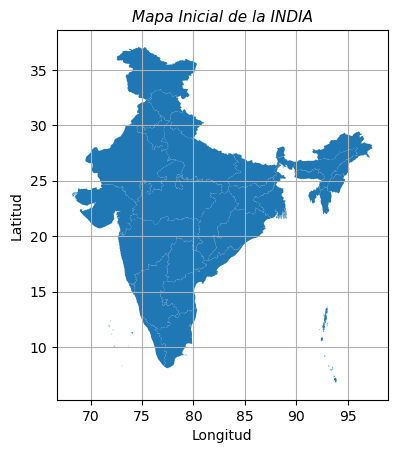

In [105]:
# Se pinta el mapa inicial de la India sin clasificación de calidad
# Los estados sin datos aparecen en gris claro
dfMAP.plot(missing_kwds={'color': 'lightgrey'})
plt.title("Mapa Inicial de la INDIA", fontsize=11, style='italic')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid()
plt.show()

#### *-Se requiere superponer las etiquetas de los estados de la India en el MAPA*

In [109]:
import subprocess, sys, os
# Instalar en carpeta local del usuario (siempre tiene permisos de escritura)
target_dir = os.path.expanduser("~/pip_local_libs")
os.makedirs(target_dir, exist_ok=True)

subprocess.check_call([
  sys.executable, "-m", "pip", "install",
  "--target", target_dir,
  "adjustText", "--quiet"
])

# Agregar la carpeta al path del kernel en esta sesión
if target_dir not in sys.path:
  sys.path.insert(0, target_dir)

from adjustText import adjust_text
print("adjustText cargado correctamente")

adjustText cargado correctamente


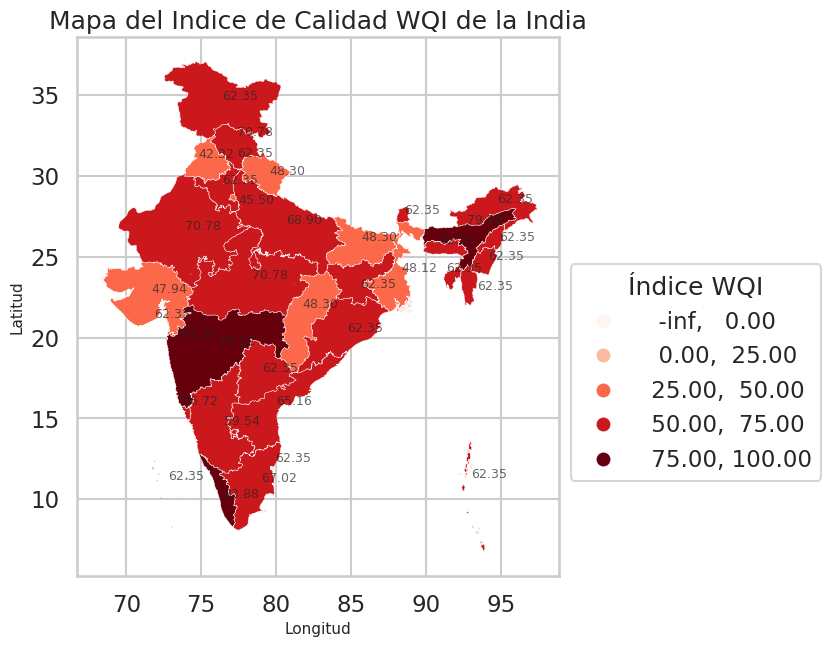

In [110]:
#Se verifica los valores NULOS; en caso de que existan se cambian por el promedio
#Se toma la ruta corta (la imputación de valores nulos puede ser mejor tratada)
dfMAP['WQI'] = dfMAP['WQI'].fillna(dfMAP['WQI'].median())

## Configuración de Estilos para ser usados en la impresión con seaborn
sns.set_context("talk") #puede ser cualquiera
sns.set_style("whitegrid") #Puede ser cualquiera de la biblioteca de estilos de seaborn

#Se ajusta el mapa 
fig, ax = plt.subplots(figsize = (12,7))
#dibujar el mapa
dfMAP.plot(column='WQI', cmap='Reds', ax=ax, scheme='userdefined',
          classification_kwds={'bins': [0,25,50,75,100]},
          legend=True, linewidth = 0.3)

##Ajustar la leyenda
leg = ax.get_legend()
leg.set_title('Índice WQI')
leg.set_bbox_to_anchor((1,0.6))

## Se agregan las etiquetas sin superposición (tener cuidado con el tamaño del PLOT)
textos = []
for _, row in dfMAP.iterrows():
    if not np.isnan(row['WQI']):
        centroide = row.geometry.centroid
        texto = ax.annotate(f"{row['WQI']:.2f}", xy=(centroide.x, centroide.y),
                           fontsize=9, alpha=0.7)
        textos.append(texto)
    
#Ajustar texto de etiquetas
adjust_text(textos, ax=ax, force_points=(0.2, 0.2))

### CARPINTERIA
ax.set_title("Mapa del Indice de Calidad WQI de la India")
ax.set_xlabel("Longitud", fontsize=11)
ax.set_ylabel("Latitud", fontsize=11)
plt.show()

### **Histograma de WQI por Estado**

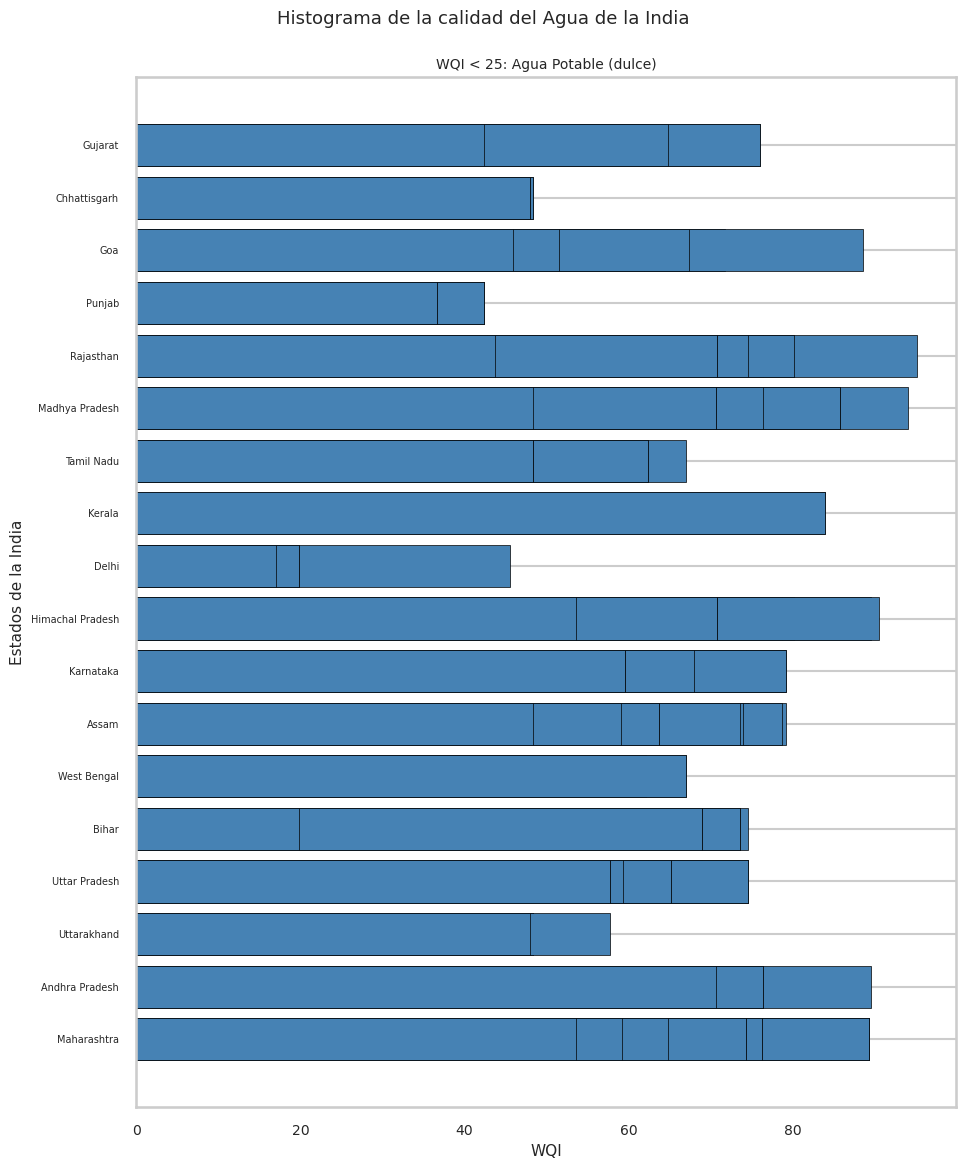

In [115]:
# Se crea una vista temporal del DataFrame df06 para consultas SQL
df06.createOrReplaceTempView("df06_sql")

# Se extraen los nombres de los estados mediante consulta SQL y función lambda
Estados = sparkC.sql("Select STATE from df06_sql")
Estados = Estados.rdd.map(lambda row: row.STATE).collect()

# Se extraen los valores de WQI por estado mediante consulta SQL y función lambda
wqi = sparkC.sql("Select WQI from df06_sql")
wqi = wqi.rdd.map(lambda row: row.WQI).collect()

# Se grafica el histograma horizontal mostrando el WQI de cada estado de la India
plt.figure(figsize=(10, 12))
plt.barh(Estados, wqi, color='steelblue', edgecolor='black', linewidth=0.5)
plt.suptitle("Histograma de la calidad del Agua de la India", fontsize=13)
plt.title("WQI < 25: Agua Potable (dulce)", fontsize=10)
plt.xlabel("WQI", fontsize=11)
plt.ylabel("Estados de la India", fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=7)
plt.grid(axis='x')
plt.tight_layout()
plt.show()

### **Creación de Modelo: Calidad de Agua en la India**

    - Se requiere predecir el parámetro WQI
    - Se crea un DF en pandas, un vector para manipular a través de numpy las columnas de calidad: "Rangos de Calidad" 
    - Se importa Scikit-Learn, para separar los datos (Entrenamiento y Prueba)
    - Se importa Keras Sequential Layers Dense
    - Se inicializa el modelo, y se añaden las capas
    - Se compila el modelo con el optimizador ADAM junto con la función de perdida de error cuadrático
    - Se realiza el experimento sobre los datos de entrenamiento
    - Se realiza la evaluación sobre los datos de prueba; para la selección del modelo.

## **8. Modelo 1: Red Neuronal con Keras (Dense)**

Se implementa una red neuronal densa (fully connected) usando Keras para predecir el WQI
a partir de los rangos de calidad calculados en la sección anterior.

**Arquitectura:** 3 capas ocultas con 350 neuronas cada una (activación ReLU) + 1 capa de salida lineal

**Optimizador:** Adam | **Función de pérdida:** MSE (Error Cuadrático Medio)

In [116]:
df06.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal',
 'qrDO',
 'wpH',
 'wDO',
 'wCOND',
 'wBOD',
 'wNN',
 'wFecal',
 'WQI',
 'CALIDAD']

In [117]:
# Se seleccionan las columnas de características (rangos de calidad) y la variable objetivo (WQI)
dfcalidad  = df06.select('qrPH', 'qrDO', 'qrCOND', 'qrBOD', 'qrNN', 'qrFecal')
dfPredecir = df06.select('WQI')

print("Variables de entrada (features):")
dfcalidad.show(5)
print("Variable objetivo (target):")
dfPredecir.show(5)

Variables de entrada (features):
+----+----+------+-----+----+-------+
|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal|
+----+----+------+-----+----+-------+
| 100| 100|     0|   80| 100|    100|
| 100| 100|    40|   80| 100|     60|
| 100|  80|     0|   80| 100|     60|
| 100|  80|     0|   80| 100|     60|
| 100|  80|    40|   80| 100|     80|
+----+----+------+-----+----+-------+
only showing top 5 rows

Variable objetivo (target):
+-----+
|  WQI|
+-----+
|76.22|
|74.34|
|59.36|
|59.36|
|74.34|
+-----+
only showing top 5 rows



In [118]:
# Se importa la función de división de datos de Scikit-Learn
from sklearn.model_selection import train_test_split

# Se dividen los datos en conjuntos de entrenamiento (80%) y prueba (20%)
# El parámetro random_state garantiza la reproducibilidad del experimento
dataTrain, dataTest, predTrain, predTest = train_test_split(
    dfcalidad.toPandas(),
    dfPredecir.toPandas(),
    test_size=0.2,
    random_state=1
)

print(f"Total de registros: {df06.count()}")
print(f"Entrenamiento: {dataTrain.shape[0]} registros ({dataTrain.shape[1]} features)")
print(f"Prueba:        {dataTest.shape[0]} registros")

Total de registros: 534
Entrenamiento: 427 registros (6 features)
Prueba:        107 registros


In [120]:
# Se importan los módulos de Keras para la construcción de la red neuronal
import keras
from keras.models import Sequential
from keras.layers import Dense

I0000 00:00:1779913616.525249 1028739 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [121]:
# Se definen los hiperparámetros del modelo
epocas = 200  # Número de iteraciones completas sobre el conjunto de entrenamiento
lote   = 81   # Tamaño del batch (número de muestras por actualización de pesos)

# Se construye el modelo secuencial con 3 capas ocultas densas
# La función de activación ReLU evita el problema del gradiente desvaneciente
modelo01 = Sequential()
modelo01.add(Dense(350, input_dim=6, activation='relu'))  # Capa de entrada
modelo01.add(Dense(350, activation='relu'))               # Capa oculta 1
modelo01.add(Dense(350, activation='relu'))               # Capa oculta 2
modelo01.add(Dense(1,   activation='linear'))             # Capa de salida (regresión)

/opt/conda/envs/rapKernel_v4/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
W0000 00:00:1779913665.160656 1028739 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [122]:
# Se compila el modelo configurando el optimizador Adam y la función de pérdida MSE
# Adam adapta la tasa de aprendizaje para cada parámetro durante el entrenamiento
keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, amsgrad=False)
modelo01.compile(loss='mean_squared_error', optimizer='Adam', metrics=['mse'])

# Se muestra el resumen de la arquitectura del modelo
modelo01.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 350)            │         2,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 350)            │       122,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 350)            │       122,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           351 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 248,501 (970.71 KB)

 Trainable params: 248,501 (970.71 KB)

 Non-trainable params: 0 (0.00 B)

In [123]:
# Se entrena el modelo con los datos de entrenamiento durante el número de épocas definido
# El historial de entrenamiento permite analizar la convergencia del modelo
ejecutarK = modelo01.fit(dataTrain, predTrain, epochs=epocas, batch_size=lote, verbose=1)

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1344.7203 - mse: 1344.7203  
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 189.0284 - mse: 189.0284 
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 93.7384 - mse: 93.7384   
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 44.9503 - mse: 44.9503 
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 16.1771 - mse: 16.1771 
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 10.1168 - mse: 10.1168 
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.3576 - mse: 4.3576 
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8613 - mse: 1.8613 
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.2397 - mse: 1.2397 
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7458 - mse: 0.7458 
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5063 - mse: 0.5063 
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4269 - mse: 0.4269 
Epoch 13/200
6/6 ━━━━━━━━━━━

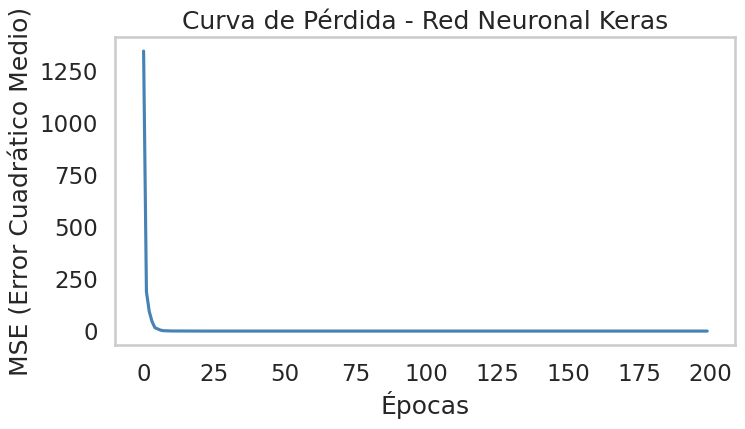

In [125]:
# Se grafica la curva de pérdida (loss) durante el entrenamiento
# Una curva decreciente indica que el modelo está aprendiendo correctamente
plt.figure(figsize=(8, 4))
plt.plot(ejecutarK.history['loss'], color='steelblue')
plt.title("Curva de Pérdida - Red Neuronal Keras")
plt.xlabel("Épocas")
plt.ylabel("MSE (Error Cuadrático Medio)")
plt.grid()
plt.show()

In [126]:
# Se evalúa el modelo sobre el conjunto de prueba para medir su capacidad de generalización
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Se generan predicciones sobre los datos de entrenamiento y de prueba
predModelo01_Train = modelo01.predict(dataTrain)
predModelo01_Test  = modelo01.predict(dataTest)

# Se calculan las métricas de rendimiento para el conjunto de prueba
mse_keras  = mean_squared_error(predTest,  predModelo01_Test)
mae_keras  = mean_absolute_error(predTest, predModelo01_Test)
rmse_keras = np.sqrt(mse_keras)
r2_keras   = r2_score(predTest, predModelo01_Test)

print("=== Métricas Modelo 1: Red Neuronal Keras ===")
print(f"MSE  (Error Cuadrático Medio):      {mse_keras:.4f}")
print(f"RMSE (Raíz del MSE):                {rmse_keras:.4f}")
print(f"MAE  (Error Absoluto Medio):        {mae_keras:.4f}")
print(f"R²   (Coef. de Determinación):      {r2_keras:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
=== Métricas Modelo 1: Red Neuronal Keras ===
MSE  (Error Cuadrático Medio):      0.2614
RMSE (Raíz del MSE):                0.5112
MAE  (Error Absoluto Medio):        0.1362
R²   (Coef. de Determinación):      0.9990


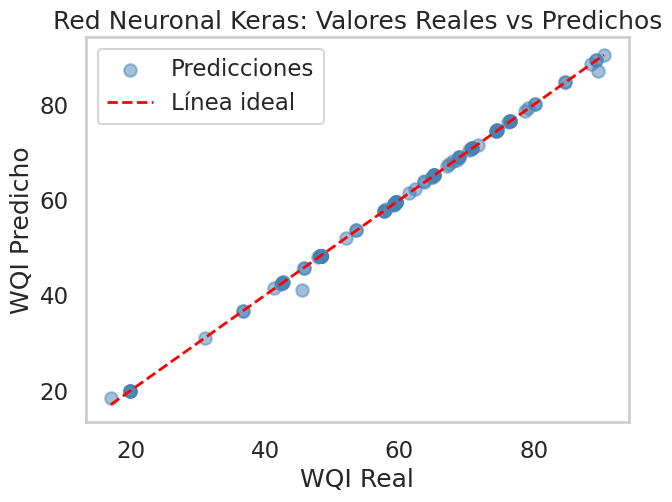

In [127]:
# Se visualiza la comparación entre los valores reales y predichos sobre el conjunto de prueba
# Una distribución cercana a la diagonal indica un buen ajuste del modelo
plt.figure(figsize=(7, 5))
plt.scatter(predTest, predModelo01_Test, alpha=0.5, color='steelblue', label='Predicciones')
plt.plot([predTest.min(), predTest.max()],
         [predTest.min(), predTest.max()],
         'r--', linewidth=2, label='Línea ideal')
plt.title("Red Neuronal Keras: Valores Reales vs Predichos")
plt.xlabel("WQI Real")
plt.ylabel("WQI Predicho")
plt.legend()
plt.grid()
plt.show()

## **9. Modelo 2: Random Forest con PySpark MLlib**

Se implementa un segundo modelo usando **Random Forest Regressor** de la biblioteca MLlib
nativa de PySpark. Este modelo es un método de ensamble basado en múltiples árboles de decisión
que reduce el sobreajuste mediante el promediado de predicciones.

**Ventaja respecto a Keras:** Es nativo de Spark, procesa los datos de forma distribuida
sin necesitar convertir el DataFrame a pandas, lo que lo hace más escalable para Big Data.

In [128]:
# Se importan los módulos de MLlib necesarios para el modelo de Random Forest
from pyspark.ml.feature    import VectorAssembler
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml            import Pipeline

print("Módulos MLlib importados correctamente")

Módulos MLlib importados correctamente


In [129]:
# Se seleccionan las columnas de características y la variable objetivo del DataFrame Spark
# Se eliminan los registros con WQI nulo para garantizar la integridad del entrenamiento
df_ml = df06.select('qrPH', 'qrDO', 'qrCOND', 'qrBOD', 'qrNN', 'qrFecal', 'WQI') \
            .dropna(subset=['WQI'])

# Se define el ensamblador de características que combina todas las columnas
# de entrada en un único vector de features requerido por MLlib
columnas_features = ['qrPH', 'qrDO', 'qrCOND', 'qrBOD', 'qrNN', 'qrFecal']
ensamblador = VectorAssembler(inputCols=columnas_features, outputCol='features')

# Se transforma el DataFrame agregando la columna 'features' con el vector ensamblado
df_vectorizado = ensamblador.transform(df_ml)

print("DataFrame vectorizado listo para MLlib:")
df_vectorizado.select('features', 'WQI').show(5, truncate=False)

DataFrame vectorizado listo para MLlib:
+----------------------------------+-----+
|features                          |WQI  |
+----------------------------------+-----+
|[100.0,100.0,0.0,80.0,100.0,100.0]|76.22|
|[100.0,100.0,40.0,80.0,100.0,60.0]|74.34|
|[100.0,80.0,0.0,80.0,100.0,60.0]  |59.36|
|[100.0,80.0,0.0,80.0,100.0,60.0]  |59.36|
|[100.0,80.0,40.0,80.0,100.0,80.0] |74.34|
+----------------------------------+-----+
only showing top 5 rows



In [130]:
# Se divide el DataFrame vectorizado en conjuntos de entrenamiento (80%) y prueba (20%)
# La semilla (seed=1) garantiza la reproducibilidad de la partición
df_train_rf, df_test_rf = df_vectorizado.randomSplit([0.8, 0.2], seed=1)

print(f"Registros de entrenamiento RF: {df_train_rf.count()}")
print(f"Registros de prueba RF:        {df_test_rf.count()}")

Registros de entrenamiento RF: 433
Registros de prueba RF:        101


In [131]:
# Se configura el modelo Random Forest con los hiperparámetros definidos
# numTrees: número de árboles en el ensamble (mayor = más robusto pero más lento)
# maxDepth: profundidad máxima de cada árbol (controla el sobreajuste)
rf = RandomForestRegressor(
    featuresCol='features',
    labelCol='WQI',
    numTrees=100,
    maxDepth=10,
    seed=1
)

# Se entrena el modelo Random Forest con los datos de entrenamiento
print("Entrenando modelo Random Forest... (puede tomar unos segundos)")
modelo_rf = rf.fit(df_train_rf)
print("Entrenamiento completado")

Entrenando modelo Random Forest... (puede tomar unos segundos)


26/05/27 15:35:14 WARN DAGScheduler: Broadcasting large task binary with size 1072.1 KiB
26/05/27 15:35:14 WARN DAGScheduler: Broadcasting large task binary with size 1262.9 KiB


Entrenamiento completado


26/05/27 15:35:14 WARN DAGScheduler: Broadcasting large task binary with size 1353.3 KiB
26/05/27 15:35:14 WARN DAGScheduler: Broadcasting large task binary with size 1158.3 KiB


In [132]:
# Se generan las predicciones del modelo sobre el conjunto de prueba
predicciones_rf = modelo_rf.transform(df_test_rf)

# Se configura el evaluador de regresión para calcular las métricas de rendimiento
evaluador = RegressionEvaluator(labelCol='WQI', predictionCol='prediction')

# Se calculan las métricas MSE, RMSE, MAE y R² para el modelo Random Forest
mse_rf  = evaluador.evaluate(predicciones_rf, {evaluador.metricName: 'mse'})
rmse_rf = evaluador.evaluate(predicciones_rf, {evaluador.metricName: 'rmse'})
mae_rf  = evaluador.evaluate(predicciones_rf, {evaluador.metricName: 'mae'})
r2_rf   = evaluador.evaluate(predicciones_rf, {evaluador.metricName: 'r2'})

print("=== Métricas Modelo 2: Random Forest MLlib ===")
print(f"MSE  (Error Cuadrático Medio):      {mse_rf:.4f}")
print(f"RMSE (Raíz del MSE):                {rmse_rf:.4f}")
print(f"MAE  (Error Absoluto Medio):        {mae_rf:.4f}")
print(f"R²   (Coef. de Determinación):      {r2_rf:.4f}")

=== Métricas Modelo 2: Random Forest MLlib ===
MSE  (Error Cuadrático Medio):      9.1848
RMSE (Raíz del MSE):                3.0306
MAE  (Error Absoluto Medio):        2.0920
R²   (Coef. de Determinación):      0.9586


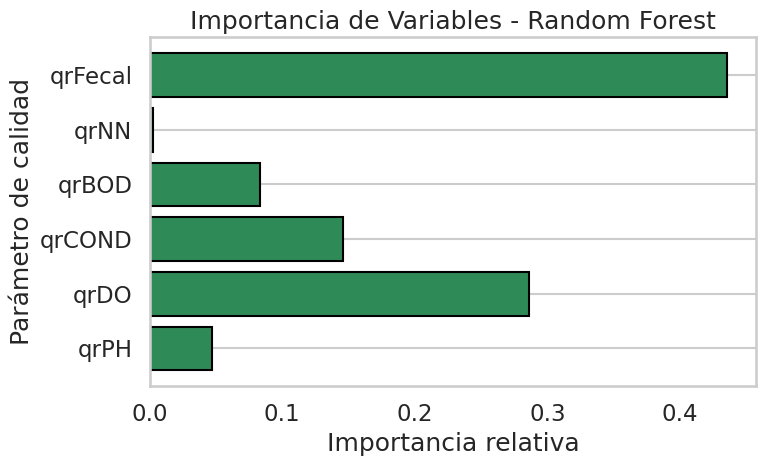

  qrPH: 0.0467
  qrDO: 0.2864
  qrCOND: 0.1460
  qrBOD: 0.0830
  qrNN: 0.0023
  qrFecal: 0.4356


In [133]:
# Se obtiene y visualiza la importancia de cada variable en el modelo Random Forest
# Permite identificar qué parámetros contribuyen más a la predicción del WQI
importancias = modelo_rf.featureImportances.toArray()

plt.figure(figsize=(8, 5))
plt.barh(columnas_features, importancias, color='seagreen', edgecolor='black')
plt.title("Importancia de Variables - Random Forest")
plt.xlabel("Importancia relativa")
plt.ylabel("Parámetro de calidad")
plt.grid(axis='x')
plt.tight_layout()
plt.show()

# Se imprime la importancia numérica de cada variable
for feat, imp in zip(columnas_features, importancias):
    print(f"  {feat}: {imp:.4f}")

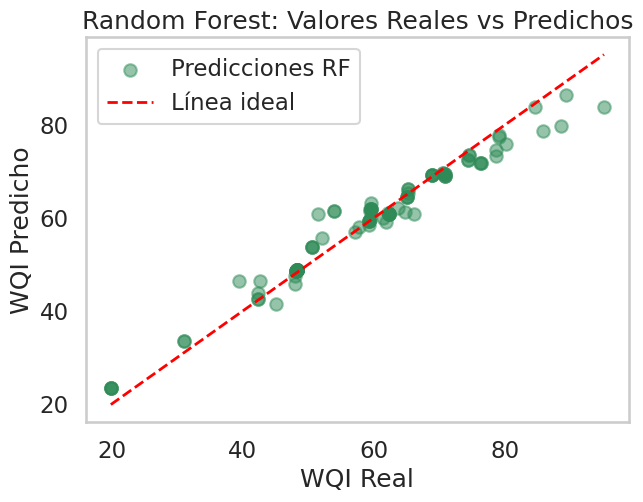

In [134]:
# Se visualiza la comparación entre valores reales y predichos del Random Forest
# Se convierte el resultado a pandas para la visualización
df_pred_rf = predicciones_rf.select('WQI', 'prediction').toPandas()

plt.figure(figsize=(7, 5))
plt.scatter(df_pred_rf['WQI'], df_pred_rf['prediction'],
            alpha=0.5, color='seagreen', label='Predicciones RF')
plt.plot([df_pred_rf['WQI'].min(), df_pred_rf['WQI'].max()],
         [df_pred_rf['WQI'].min(), df_pred_rf['WQI'].max()],
         'r--', linewidth=2, label='Línea ideal')
plt.title("Random Forest: Valores Reales vs Predichos")
plt.xlabel("WQI Real")
plt.ylabel("WQI Predicho")
plt.legend()
plt.grid()
plt.show()

## **10. Comparación de Modelos**

Se presenta una comparación cuantitativa y visual entre los dos modelos implementados:
la Red Neuronal (Keras) y el Random Forest (MLlib).

In [135]:
# Se construye una tabla comparativa con todas las métricas de ambos modelos
comparacion = pd.DataFrame({
    'Métrica': ['MSE', 'RMSE', 'MAE', 'R²'],
    'Red Neuronal Keras': [mse_keras, rmse_keras, mae_keras, r2_keras],
    'Random Forest MLlib': [mse_rf,   rmse_rf,   mae_rf,   r2_rf]
})

print("=== COMPARACIÓN DE MODELOS ===")
print(comparacion.to_string(index=False))

# Se determina el mejor modelo según el R² (mayor R² = mejor ajuste)
if r2_rf > r2_keras:
    print(f"\n→ El Random Forest obtuvo mejor R²: {r2_rf:.4f} vs {r2_keras:.4f}")
else:
    print(f"\n→ La Red Neuronal Keras obtuvo mejor R²: {r2_keras:.4f} vs {r2_rf:.4f}")

=== COMPARACIÓN DE MODELOS ===
Métrica  Red Neuronal Keras  Random Forest MLlib
    MSE            0.261374             9.184810
   RMSE            0.511247             3.030645
    MAE            0.136210             2.091952
     R²            0.998960             0.958595

→ La Red Neuronal Keras obtuvo mejor R²: 0.9990 vs 0.9586


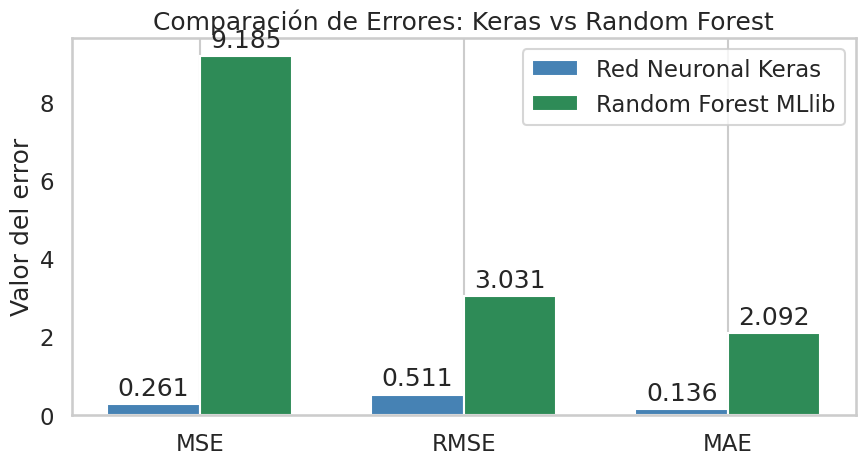

In [136]:
# Se grafica una comparación visual de las métricas MSE, RMSE y MAE entre ambos modelos
# Valores más bajos en MSE, RMSE y MAE indican mejor rendimiento del modelo
metricas   = ['MSE', 'RMSE', 'MAE']
vals_keras = [mse_keras, rmse_keras, mae_keras]
vals_rf    = [mse_rf,    rmse_rf,    mae_rf]

x = np.arange(len(metricas))
ancho = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
barras1 = ax.bar(x - ancho/2, vals_keras, ancho, label='Red Neuronal Keras',  color='steelblue')
barras2 = ax.bar(x + ancho/2, vals_rf,    ancho, label='Random Forest MLlib', color='seagreen')

ax.set_title('Comparación de Errores: Keras vs Random Forest')
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.set_ylabel('Valor del error')
ax.legend()
ax.bar_label(barras1, fmt='%.3f', padding=3)
ax.bar_label(barras2, fmt='%.3f', padding=3)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

## Conclusiones, observaciones y referencias

## **11. Conclusiones**

### **Comparación de Modelos**
Ambos modelos lograron coeficientes de determinación superiores al 95%, lo que demuestra
que los rangos de calidad calculados (`qrPH`, `qrDO`, `qrCOND`, `qrBOD`, `qrNN`, `qrFecal`)
son predictores altamente informativos del WQI. Sin embargo, existieron diferencias
significativas en precisión:

| Métrica | Red Neuronal Keras | Random Forest MLlib |
|---------|-------------------|---------------------|
| MSE     | **0.2614**        | 9.1848              |
| RMSE    | **0.5112**        | 3.0306              |
| MAE     | **0.1362**        | 2.0920              |
| R²      | **0.9990**        | 0.9586              |

La Red Neuronal Keras superó al Random Forest en todas las métricas. Esto se explica porque
el WQI es una combinación lineal ponderada de los rangos de calidad — una estructura que las
redes neuronales con descenso de gradiente pueden aproximar con altísima precisión una vez
que los pesos de la red convergen hacia los pesos reales de la fórmula.

### **Ventajas y Limitaciones de cada Enfoque**
- **Keras** ofrece mayor precisión numérica para este dataset, pero requiere convertir los
DataFrames de Spark a pandas (`toPandas()`), lo que representa un cuello de botella
en escenarios de Big Data real con millones de registros.
- **Random Forest MLlib** opera de forma nativa y distribuida sobre Spark, sin necesidad
de materializar los datos en memoria local. Para datasets de escala industrial
(millones de filas distribuidas en múltiples nodos), esta ventaja arquitectónica
supera la diferencia en precisión observada en este experimento.

### **Sobre el Entorno Distribuido PySpark**
El uso del clúster Hadoop/Spark permitió procesar los datos de forma paralela y distribuida.
La integración de MLlib con el pipeline de Spark (`VectorAssembler` → `RandomForestRegressor`
→ `RegressionEvaluator`) demuestra la potencia del ecosistema para construir flujos de
machine learning reproducibles y escalables sin salir del entorno distribuido.

### **Conclusión General**
Este taller demostró que las técnicas de Procesamiento de Datos en Alto Volumen (PAVD)
aplicadas al diagnóstico de calidad del agua son viables y efectivas. La combinación de
PySpark para el procesamiento masivo de datos, MLlib para modelos distribuidos escalables,
y Keras para predicciones de alta precisión en etapas de análisis, representa una
arquitectura complementaria y poderosa para abordar problemas reales de salud pública
a escala nacional o global.

## **12. Observaciones**

### **Sobre los Datos y el Preprocesamiento**
- El dataset contiene **534 registros** correspondientes a estaciones de medición distribuidas
en los estados de la India. Tras el filtrado de valores nulos en los parámetros clave,
el volumen de datos se mantuvo sin pérdida significativa, lo que indica una buena calidad
de captura en la fuente original.
- La conversión de tipos de `String` a `FloatType` fue necesaria porque PySpark carga los
campos CSV como cadenas de texto por defecto. Este paso es crítico: sin él, las operaciones
matemáticas para calcular rangos y el WQI fallarían silenciosamente.
- La eliminación de `TOTAL_COLIFORM` fue adecuada: su alta correlación con `FECAL_COLIFORM`
introduce redundancia que puede afectar la convergencia de modelos sensibles a multicolinealidad.

### **Sobre los Parámetros de Calidad del Agua**
- Las gráficas de series temporales (DO, pH, BOD, Nitratos, Conductividad, Coliformes Fecales)
mostraron alta variabilidad entre estaciones, evidenciando heterogeneidad significativa en la
calidad del agua a lo largo de los ríos de la India.
- El parámetro `FECAL_COLIFORM` presentó los valores más dispersos, con picos extremos que
corresponden a zonas industriales o densamente pobladas, lo que explica su alto peso en la
predicción del WQI.
- Los parámetros `DO` y `pH` mostraron comportamientos más estables, consistentes con ríos
que aún conservan cierta capacidad de autodepuración.

  ### **Sobre el Índice WQI y el Mapa**
  - El mapa coroplético reveló una distribución no uniforme del WQI: los estados del noreste
    de la India tendieron a presentar mejores índices que los estados del norte y el cinturón
    industrial del centro.
  - El histograma de WQI por estado confirmó que la mayoría de las estaciones caen en la
    categoría **"Baja"** (WQI entre 50 y 75), indicando que el agua requiere tratamiento antes
    del consumo humano.

  ### **Sobre los Modelos**
  - **Red Neuronal Keras:** La curva de pérdida (loss) convergió progresivamente durante las
    200 épocas, alcanzando valores muy bajos de MSE, lo que indica que el modelo aprendió
    la relación entre los rangos de calidad y el WQI de manera efectiva.
    Métricas finales sobre el conjunto de prueba:
    `MSE = 0.2614 | RMSE = 0.5112 | MAE = 0.1362 | R² = 0.9990`

  - **Random Forest MLlib:** El modelo de ensamble con 100 árboles y profundidad máxima de 10
    también logró un buen ajuste, aunque con errores notablemente mayores que Keras.
    Métricas finales sobre el conjunto de prueba:
    `MSE = 9.1848 | RMSE = 3.0306 | MAE = 2.0920 | R² = 0.9586`

  - **Importancia de variables (Random Forest):**
    El gráfico de importancias reveló que `qrFecal` (43.56%) y `qrDO` (28.64%) son los
    parámetros con mayor poder predictivo del WQI, mientras que `qrNN` (0.23%) contribuye
    de forma casi nula. Esto es coherente con la fórmula del WQI, donde los pesos de
    Coliformes Fecales y Oxígeno Disuelto son los más altos (0.281 cada uno).